# Clustering Case Study — Customer Segmentation

## Discover stable, interpretable groups without labels

This self-contained case study uses reproducible synthetic data. Every major step produces a result table and chart. The numbers illustrate a workflow and are not claims about real people or businesses.

In [1]:
from pathlib import Path
import json, warnings, joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2563eb", "#059669", "#f59e0b", "#dc2626", "#64748b"]
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.options.display.float_format = "{:,.3f}".format

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

mkdir -p failed for path C:\Users\jacob\AppData\Local\matplotlib: [WinError 5] Access is denied: 'C:\\Users\\jacob\\AppData\\Local\\matplotlib'


Matplotlib created a temporary cache directory at C:\Users\jacob\AppData\Local\Temp\matplotlib-j47dxofu because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Define the unsupervised-learning contract

Clusters are useful only if they lead to differentiated, testable actions.

,item,definition,importance
0,Decision,Design segment-specific experiences,5
1,Unit,One active customer,5
2,Objective,"Compact, separated, stable groups",4
3,Selection metric,Silhouette plus business interpretability,4
4,Guardrail,No protected attributes in fitting,5


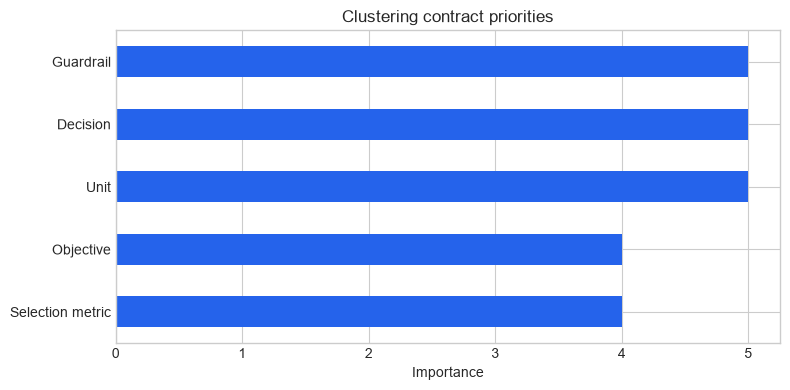

In [2]:
contract=pd.DataFrame([("Decision","Design segment-specific experiences",5),("Unit","One active customer",5),("Objective","Compact, separated, stable groups",4),("Selection metric","Silhouette plus business interpretability",4),("Guardrail","No protected attributes in fitting",5)],columns=["item","definition","importance"])
display(contract); ax=contract.sort_values("importance").plot.barh(x="item",y="importance",legend=False,color=COLORS[0],figsize=(8,4)); ax.set(title="Clustering contract priorities",xlabel="Importance",ylabel=""); plt.tight_layout(); plt.show()

## 2. Generate and validate synthetic behavior data

,monthly_spend,sessions_per_month,discount_share,support_contacts
0,146.776,10.247,0.620,3.983
1,33.185,14.159,0.373,3.071
2,131.160,20.165,0.379,1.106
3,92.800,19.737,0.068,0.277
4,46.568,17.287,0.150,3.822
5,49.161,9.838,0.453,2.333
6,99.551,18.054,0.210,2.841
7,70.875,14.689,0.501,3.608


,min,median,max,missing_n
monthly_spend,10.000,99.464,201.234,0
sessions_per_month,1.000,14.499,33.895,90
discount_share,0.000,0.362,0.755,0
support_contacts,0.000,2.783,6.283,0


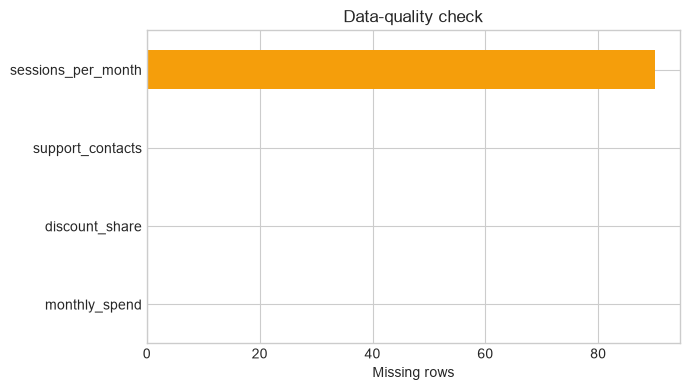

In [3]:
X_raw,true_segment=make_blobs(n_samples=4500,centers=[[-1.6,-.7,1.1,.3],[1.2,1.8,-.5,-1.2],[2.0,-1.2,1.6,1.5],[-.5,1.0,-1.6,.8]],cluster_std=[.55,.7,.6,.65],random_state=RANDOM_STATE)
df=pd.DataFrame({"monthly_spend":np.clip(90+28*X_raw[:,0],10,None),"sessions_per_month":np.clip(14+5*X_raw[:,1],1,None),"discount_share":np.clip(.32+.12*X_raw[:,2],0,.85),"support_contacts":np.clip(2.2+1.1*X_raw[:,3],0,None)})
df.loc[rng.choice(len(df),90,replace=False),"sessions_per_month"]=np.nan
quality=pd.DataFrame({"min":df.min(),"median":df.median(),"max":df.max(),"missing_n":df.isna().sum()})
display(df.head(8)); display(quality)
ax=quality.missing_n.sort_values().plot.barh(color=COLORS[2],figsize=(7,4)); ax.set(title="Data-quality check",xlabel="Missing rows",ylabel=""); plt.tight_layout(); plt.show()

## 3. Explore behavioral structure before fitting

,mean,std,min,50%,max
monthly_spend,98.148,43.216,10.000,99.464,201.234
sessions_per_month,15.110,6.813,1.000,14.499,33.895
discount_share,0.337,0.170,0.000,0.362,0.755
support_contacts,2.607,1.252,0.000,2.783,6.283


,monthly_spend,sessions_per_month,discount_share,support_contacts
monthly_spend,1.000,0.014,0.158,0.039
sessions_per_month,0.014,1.000,-0.692,-0.568
discount_share,0.158,-0.692,1.000,0.277
support_contacts,0.039,-0.568,0.277,1.000


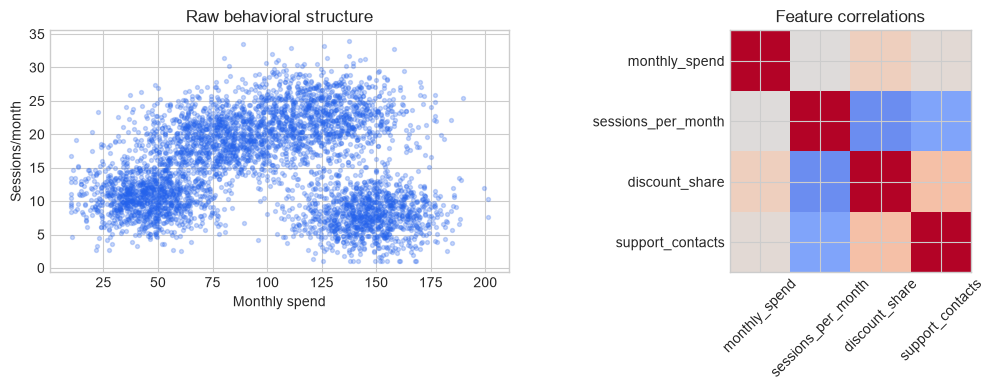

In [4]:
summary=df.describe().T[["mean","std","min","50%","max"]]; corr=df.corr(numeric_only=True)
display(summary); display(corr)
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].scatter(df.monthly_spend,df.sessions_per_month,s=8,alpha=.25,color=COLORS[0]); axes[0].set(title="Raw behavioral structure",xlabel="Monthly spend",ylabel="Sessions/month")
im=axes[1].imshow(corr,cmap="coolwarm",vmin=-1,vmax=1); axes[1].set(xticks=range(len(corr)),yticks=range(len(corr)),xticklabels=corr.columns,yticklabels=corr.columns,title="Feature correlations"); axes[1].tick_params(axis="x",rotation=45); plt.tight_layout(); plt.show()

## 4. Impute and scale features

Distance-based methods require comparable units.

,raw_mean,raw_std,scaled_mean,scaled_std
monthly_spend,98.148,43.216,-0.000,1.000
sessions_per_month,15.098,6.745,-0.000,1.000
discount_share,0.337,0.170,-0.000,1.000
support_contacts,2.607,1.252,0.000,1.000


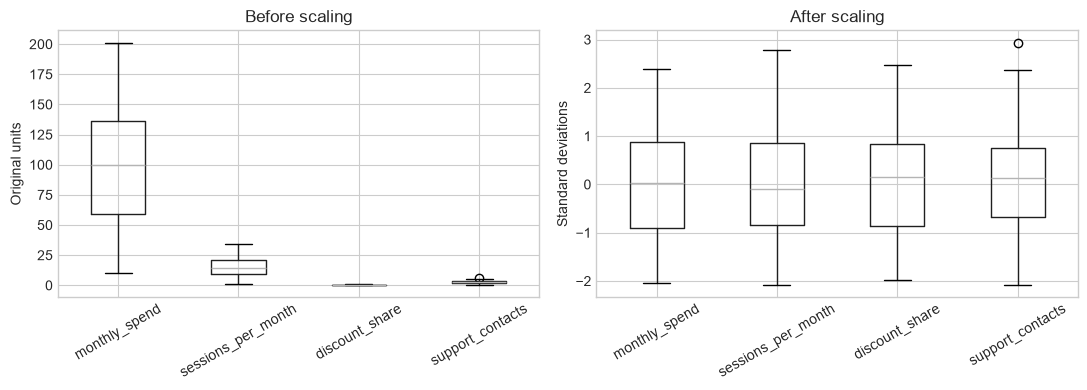

In [5]:
prepared=df.fillna(df.median()); scaler=StandardScaler(); Z=scaler.fit_transform(prepared)
scale_table=pd.DataFrame({"raw_mean":prepared.mean(),"raw_std":prepared.std(),"scaled_mean":Z.mean(axis=0),"scaled_std":Z.std(axis=0)},index=df.columns)
display(scale_table)
fig,axes=plt.subplots(1,2,figsize=(11,4)); prepared.boxplot(ax=axes[0],rot=30); axes[0].set(title="Before scaling",ylabel="Original units")
pd.DataFrame(Z,columns=df.columns).boxplot(ax=axes[1],rot=30); axes[1].set(title="After scaling",ylabel="Standard deviations"); plt.tight_layout(); plt.show()

## 5. Select the number of clusters

,k,inertia,silhouette
0,2,"10,506.961",0.392
1,3,"6,710.638",0.453
2,4,"3,869.302",0.510
3,5,"3,630.084",0.426
4,6,"3,428.341",0.373
5,7,"3,245.899",0.276
6,8,"3,075.444",0.191


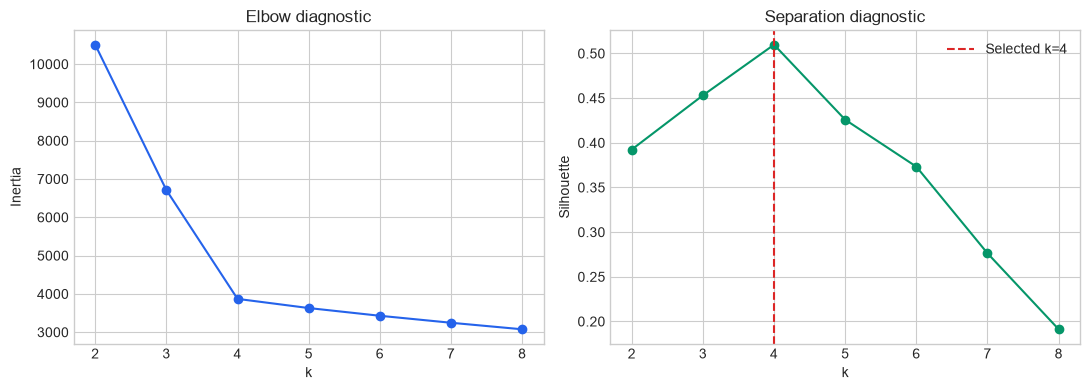

In [6]:
rows=[]
for k in range(2,9):
    km=KMeans(n_clusters=k,n_init=20,random_state=RANDOM_STATE).fit(Z)
    rows.append((k,km.inertia_,silhouette_score(Z,km.labels_)))
selection=pd.DataFrame(rows,columns=["k","inertia","silhouette"]); best_k=int(selection.loc[selection.silhouette.idxmax(),"k"])
display(selection)
fig,axes=plt.subplots(1,2,figsize=(11,4)); axes[0].plot(selection.k,selection.inertia,marker="o",color=COLORS[0]); axes[0].set(title="Elbow diagnostic",xlabel="k",ylabel="Inertia")
axes[1].plot(selection.k,selection.silhouette,marker="o",color=COLORS[1]); axes[1].axvline(best_k,color=COLORS[3],ls="--",label=f"Selected k={best_k}"); axes[1].set(title="Separation diagnostic",xlabel="k",ylabel="Silhouette"); axes[1].legend(); plt.tight_layout(); plt.show()

## 6. Fit, visualize, and profile the selected clusters

,customers
0,1125
1,1127
2,1116
3,1132


monthly_spend         sessions_per_month        discount_share         \
                 mean  median               mean median           mean median   
cluster                                                                         
0             146.158 146.197              8.174  8.005          0.510  0.510   
1              77.467  77.601             19.011 19.030          0.129  0.128   
2             123.873 124.107             22.694 22.818          0.257  0.253   
3              45.665  45.866             10.594 10.594          0.450  0.451   

        support_contacts         
                    mean median  
cluster                          
0                  3.836  3.862  
1                  3.117  3.101  
2                  0.919  0.897  
3                  2.542  2.544

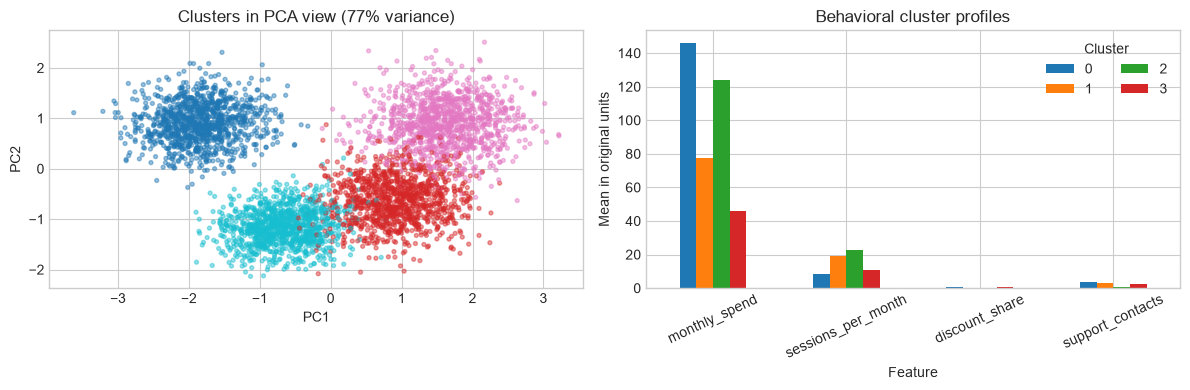

In [7]:
model=KMeans(n_clusters=best_k,n_init=30,random_state=RANDOM_STATE).fit(Z); labels=model.labels_
profile=prepared.assign(cluster=labels).groupby("cluster").agg(["mean","median"]); sizes=pd.Series(labels).value_counts().sort_index().rename("customers")
pca=PCA(n_components=2,random_state=RANDOM_STATE); coords=pca.fit_transform(Z)
display(sizes.to_frame()); display(profile)
fig,axes=plt.subplots(1,2,figsize=(12,4)); axes[0].scatter(coords[:,0],coords[:,1],c=labels,s=8,alpha=.45,cmap="tab10"); axes[0].set(title=f"Clusters in PCA view ({pca.explained_variance_ratio_.sum():.0%} variance)",xlabel="PC1",ylabel="PC2")
profile.xs("mean",axis=1,level=1).T.plot.bar(ax=axes[1],rot=25); axes[1].set(title="Behavioral cluster profiles",ylabel="Mean in original units",xlabel="Feature"); axes[1].legend(title="Cluster",ncol=2); plt.tight_layout(); plt.show()

## 7. Test stability and package the segmentation pipeline

,count,mean,std,min,25%,50%,75%,max
seed,10.000,4.500,3.028,0.000,2.250,4.500,6.750,9.000
silhouette,10.000,0.509,0.001,0.507,0.508,0.509,0.510,0.512


,artifact,size_kb
0,cluster_assignments.csv,338.791
1,segmentation_pipeline.joblib,19.243


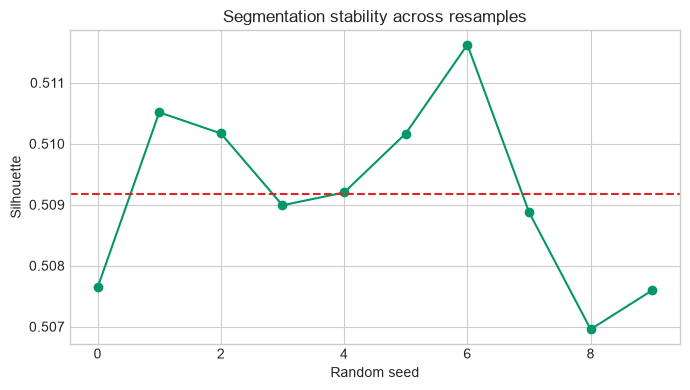

In [8]:
stability=[]
for seed in range(10):
    sample=rng.choice(len(Z),int(.8*len(Z)),replace=False); km=KMeans(n_clusters=best_k,n_init=10,random_state=seed).fit(Z[sample]); stability.append((seed,silhouette_score(Z[sample],km.labels_)))
stability=pd.DataFrame(stability,columns=["seed","silhouette"])
artifact_dir=Path("clustering_artifacts"); artifact_dir.mkdir(exist_ok=True); joblib.dump({"scaler":scaler,"model":model,"features":list(df.columns)},artifact_dir/"segmentation_pipeline.joblib")
prepared.assign(cluster=labels).to_csv(artifact_dir/"cluster_assignments.csv",index=False)
display(stability.describe().T); display(pd.DataFrame({"artifact":[p.name for p in artifact_dir.iterdir()],"size_kb":[p.stat().st_size/1024 for p in artifact_dir.iterdir()]}))
ax=stability.plot(x="seed",y="silhouette",marker="o",legend=False,color=COLORS[1],figsize=(7,4)); ax.axhline(stability.silhouette.mean(),ls="--",color=COLORS[3]); ax.set(title="Segmentation stability across resamples",ylabel="Silhouette",xlabel="Random seed"); plt.tight_layout(); plt.show()

## Conclusion

Clustering is exploratory. Validate separation, stability, interpretability, and downstream experimental value before assigning durable segment names or actions.